In [1]:
%load_ext autoreload
%autoreload 2
from utils.plotting import *
from results.results import *

In [2]:
# LOOKING FOR FOLDERS

# filter all folder name in rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" that contain "finetune_20251030-232939_model_20"

rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"
dir_path_seeds = []
for folder_name in os.listdir(rel_path):
    if "20251101-233338" in folder_name:
        dir_path_seeds.append(os.path.join(folder_name))

# print line by line dir_path_seeds
for path in dir_path_seeds:
    print(f"\"{path}\",")

In [3]:
# getting results
rel_path = "/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000"

# dir_path_seeds = fsnet_ft_ckpt20_subopt20_over_train_size
# dir_path_seeds = fsnet_ft_ckpt20_subopt00_over_train_size
# dir_path_seeds = fsnet_ft_ckpt20_train_size7000_over_subopt
# dir_path_seeds = fsnet_ft_subopt100_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt60_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt40_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt20_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt10_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt05_train_size7000_over_ckpt
# dir_path_seeds = fsnet_ft_subopt00_train_size7000_over_ckpt

# dir_path_seeds = dc3_ft_subopt60_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_subopt40_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_subopt20_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_subopt10_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_subopt05_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_subopt00_train_size7000_over_ckpt
# dir_path_seeds = dc3_ft_ckpt20_train_size7000_over_subopt

dir_path_seeds = penalty_ft_ckpt20_subopt20_over_train_size
# dir_path_seeds = penalty_ft_ckpt20_train_size7000_over_subopt
# dir_path_seeds = penalty_ft_subopt100_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt60_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt40_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt20_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt10_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt05_train_size7000_over_ckpt
# dir_path_seeds = penalty_ft_subopt00_train_size7000_over_ckpt

# collecting data
opt_gap_mean = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_max = np.zeros_like(dir_path_seeds, dtype=float)
opt_gap_std = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
eq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_mean = np.zeros_like(dir_path_seeds, dtype=float)
ineq_violation_l1_max = np.zeros_like(dir_path_seeds, dtype=float)

batch_size = 256
for i in range(dir_path_seeds.shape[0]):  # over ckpt
    for j in range(dir_path_seeds.shape[1]):  # over seeds
        dir_path = os.path.join(
            rel_path, dir_path_seeds[i, j]
        )
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            print(dir_path)
            results = pickle.load(f)
            results_ = results['test_results']['batch_size_comparison'][batch_size]['metrics']
        opt_gap_mean[i, j] = results_["opt_gap_mean"]
        opt_gap_max[i, j] = results_["opt_gap_max"]
        opt_gap_std[i, j] = results_["opt_gap_std"]
        eq_violation_l1_mean[i, j] = results_["eq_violation_l1_mean"]
        eq_violation_l1_max[i, j] = results_["eq_violation_l1_max"]
        ineq_violation_l1_mean[i, j] = results_["ineq_violation_l1_mean"]
        ineq_violation_l1_max[i, j] = results_["ineq_violation_l1_max"]
        
# assuming you already have: dir_path_seeds, rel_path
num_baselines = dir_path_seeds.shape[0]
num_seeds = dir_path_seeds.shape[1]
print(num_baselines, num_seeds)

# read one file to know number of epochs
with open(os.path.join(rel_path, dir_path_seeds[0, 0], "results.pkl"), "rb") as f:
    results = pickle.load(f)
    num_epochs = len(results["val_history"])

# store [num_baselines, num_seeds, num_epochs]
opt_gap_mean_epochs = np.zeros((num_baselines, num_seeds, num_epochs))

for i in range(num_baselines):  # over ckpt
    for j in range(num_seeds):  # over seed
        dir_path = os.path.join(rel_path, dir_path_seeds[i, j])
        with open(os.path.join(dir_path, "results.pkl"), "rb") as f:
            results = pickle.load(f)
            results_ = results["val_history"]
            opt_gap_mean_epochs[i, j, :] = [r["opt_gap_mean"] for r in results_]

FileNotFoundError: [Errno 2] No such file or directory: '/home/khain/FSNet/results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251106-115116_MLP_penalty_seed0_dropout0.1_finetune_20251103-103706_model_20/results.pkl'

'objective', 'true_objective',
'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
'eq_violation_l2_mean', 'eq_violation_l2_max',
'ineq_violation_l2_mean', 'ineq_violation_l2_max',
'eq_violation_l1_mean', 'eq_violation_l1_max',
'ineq_violation_l1_mean', 'ineq_violation_l1_max',
'eq_violation_max_mean', 'eq_violation_max_max',
'ineq_violation_max_mean', 'ineq_violation_max_max',
'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'

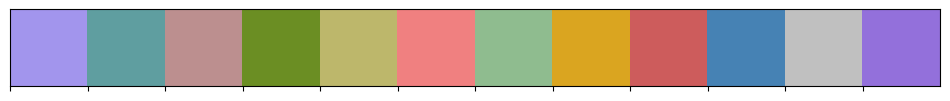

In [ ]:
colors = [
    ["#a295ed"],  # soft lavender
    ["#5F9EA0"],  # cadet blue
    ["#BC8F8F"],  # rosy brown
    ["#6B8E23"],  # olive drab
    ["#BDB76B"],  # dark khaki
    ["#F08080"],  # light coral
    ["#8FBC8F"],  # dark sea green
    ["#DAA520"],  # goldenrod
    ["#CD5C5C"],  # indian red
    ["#4682B4"],  # steel blue
    ["#C0C0C0"],  # silver gray
    ["#9370DB"],  # medium purple
]
sns.palplot([c[0] for c in colors])

/orcd/home/002/khain/FSNet/utils/plotting.py:156: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


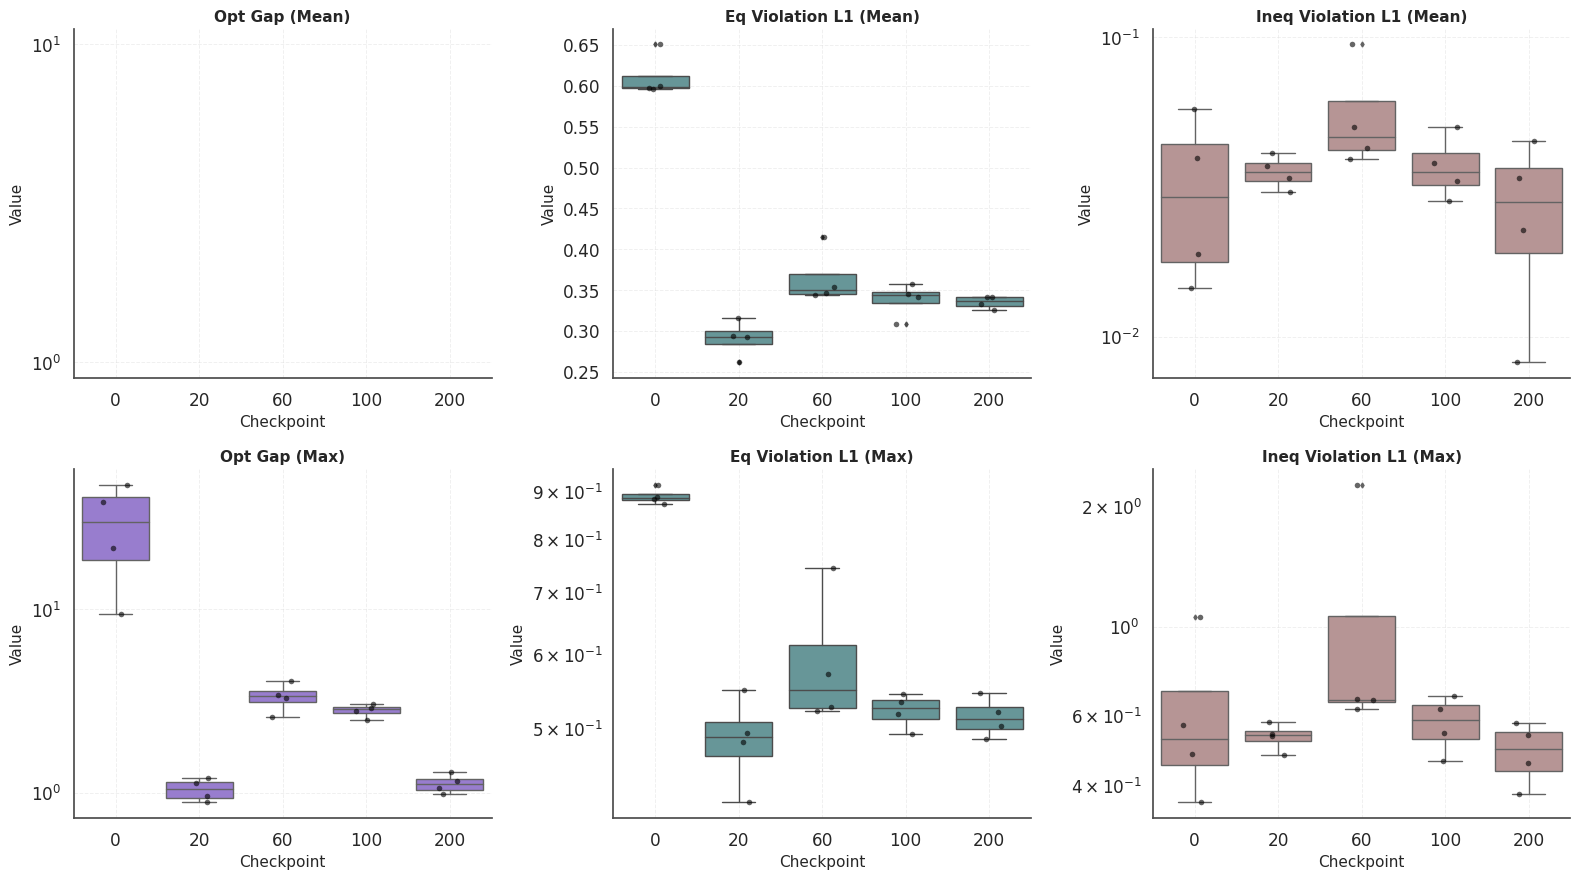

In [ ]:
# === define all metrics and plot settings ===
checkpoints = np.array([0, 20, 60, 100, 200])
select = [0, 1, 2, 3, 4]

# plot_box_with_points(
#     [opt_gap_mean[select]],
#     ["Opt Gap (Mean)"],
#     checkpoints,
#     x_label="Checkpoint",
#     title="",
#     log_scale_y=False,
#     figsize=(5, 4),
#     palette=colors[-1],
# )

metrics = [ 
    (opt_gap_mean[select], "Opt Gap (Mean)", True, colors[-1]),
    (eq_violation_l1_mean[select], "Eq Violation L1 (Mean)", False, colors[1]),
    (ineq_violation_l1_mean[select], "Ineq Violation L1 (Mean)", True, colors[2]),
    (opt_gap_max[select], "Opt Gap (Max)", True, colors[-1]),
    (eq_violation_l1_max[select], "Eq Violation L1 (Max)", True, colors[1]),
    (ineq_violation_l1_max[select], "Ineq Violation L1 (Max)", True, colors[2]),
]

plot_metrics_grid(
    metrics,
    checkpoints[select],
    nrows=2, ncols=3,
    figsize=(16, 9),
    x_label="Checkpoint",
    y_label="Value",
)

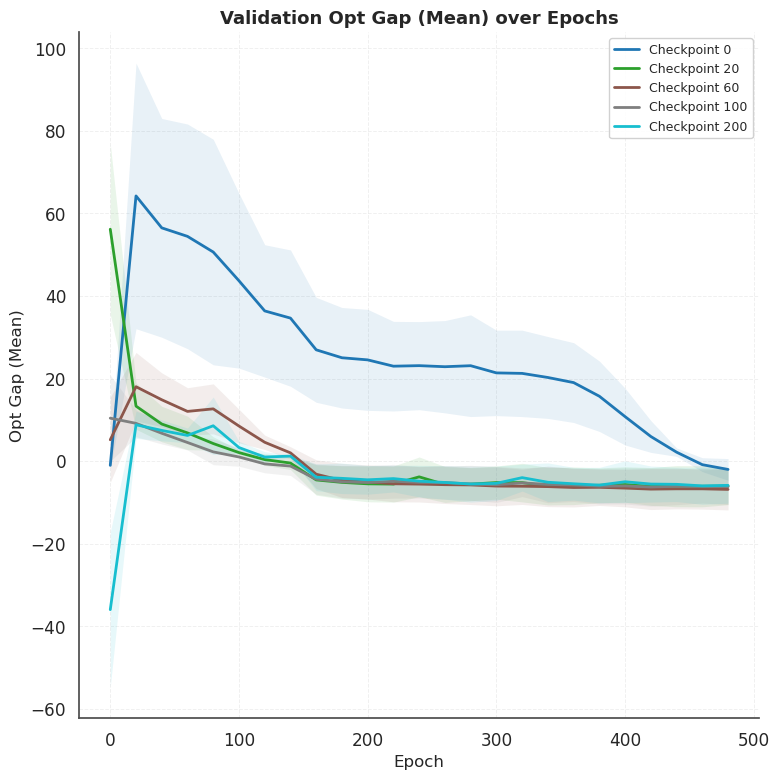

In [ ]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs[select],   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=checkpoints[select],
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    label="Checkpoint",
    log_scale_y=False,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
    figsize=(8, 8),
)

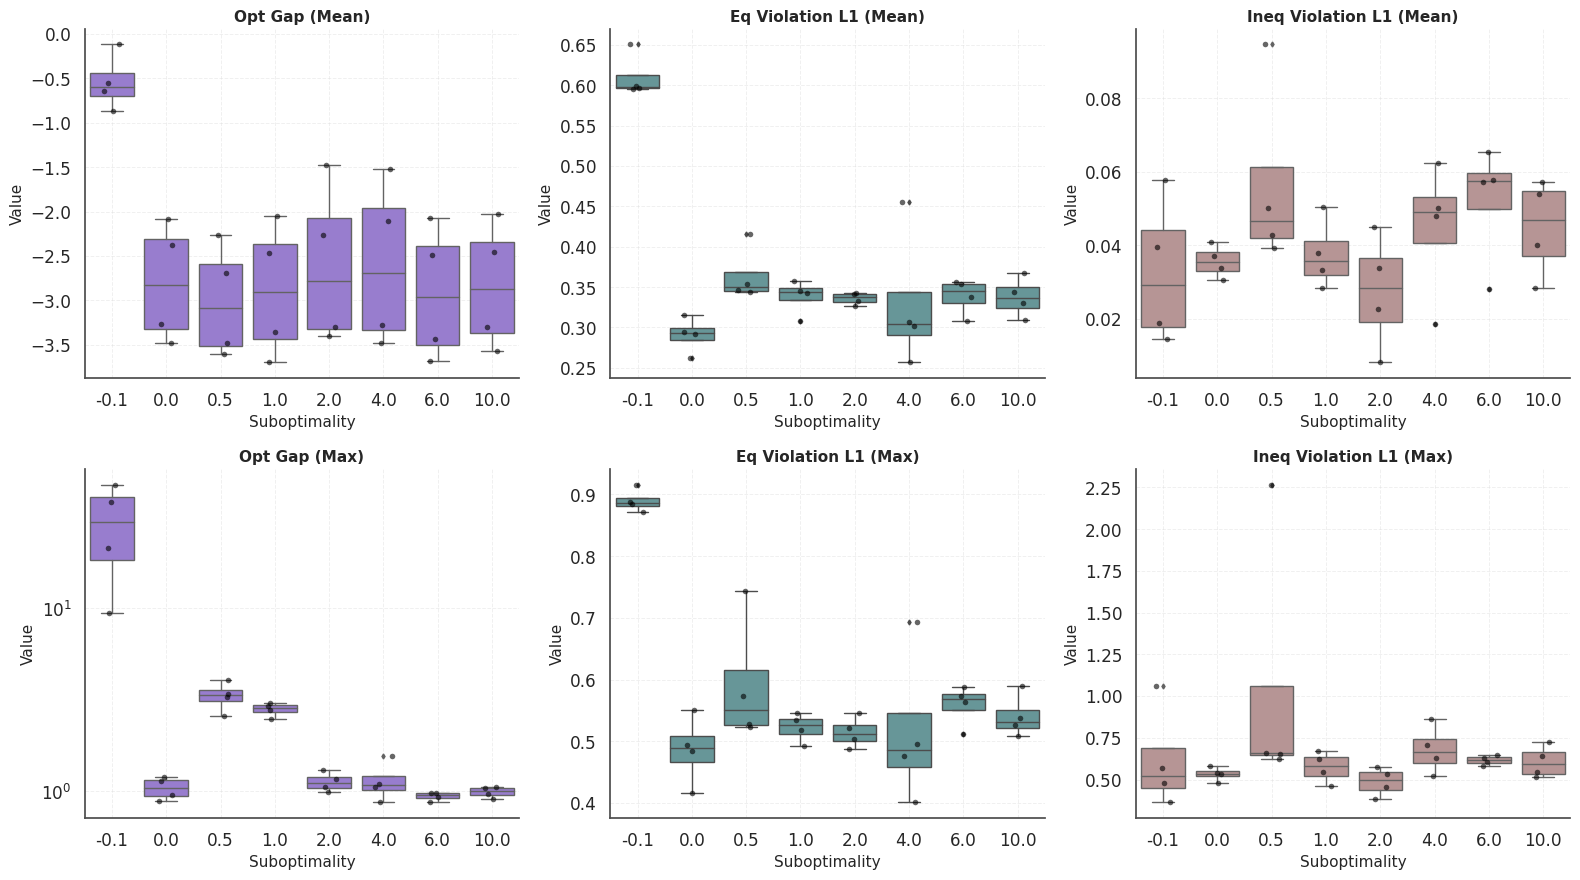

In [ ]:
# PLOTS FOR DIFFERENT SUBOPTIMALITIES

subopts = np.array([-0.1, 0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 10.0])
select = [0, 1, 2, 3, 4, 5, 6, 7]

# plot_box_with_points(
#     [opt_gap_mean[select]],
#     ["Opt Gap (Mean)"],
#     subopts[select],
#     x_label="Suboptimality",
#     title="",
#     log_scale_y=False,
#     figsize=(4, 4),
# )

metrics = [ 
    (opt_gap_mean[select], "Opt Gap (Mean)", False, colors[-1]),
    (eq_violation_l1_mean[select], "Eq Violation L1 (Mean)", False, colors[1]),
    (ineq_violation_l1_mean[select], "Ineq Violation L1 (Mean)", False, colors[2]),
    (opt_gap_max[select], "Opt Gap (Max)", True, colors[-1]),
    (eq_violation_l1_max[select], "Eq Violation L1 (Max)", False, colors[1]),
    (ineq_violation_l1_max[select], "Ineq Violation L1 (Max)", False, colors[2]),
]

plot_metrics_grid(
    metrics,
    subopts[select],
    nrows=2, ncols=3,
    figsize=(16, 9),
    x_label="Suboptimality",
    y_label="Value",
)

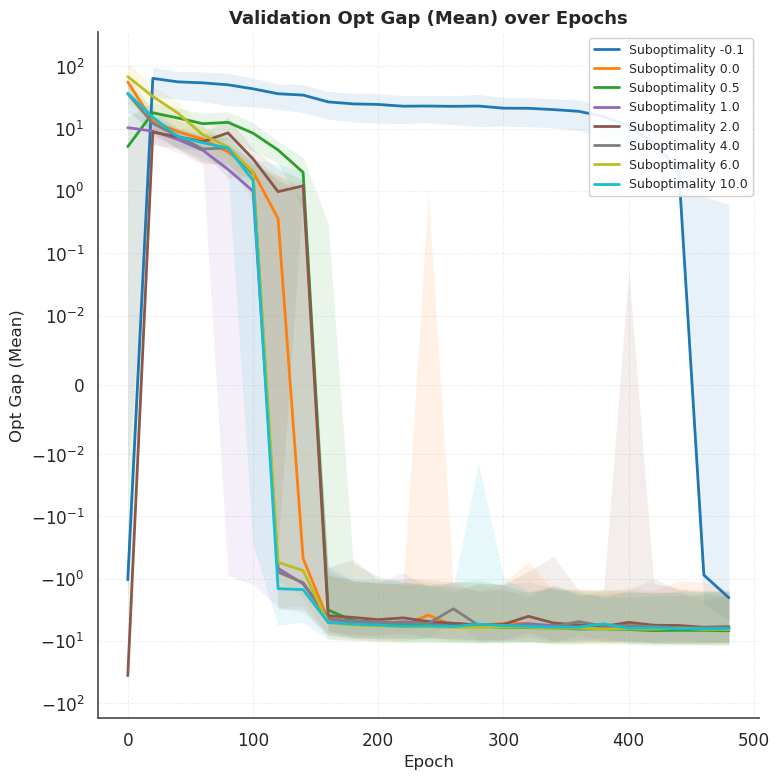

In [ ]:
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs[select],   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=subopts[select],
    metric_name="Opt Gap (Mean)",
    # title="Validation Opt Gap Mean per Checkpoint",
    label="Suboptimality",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
    figsize=(8, 8),
)

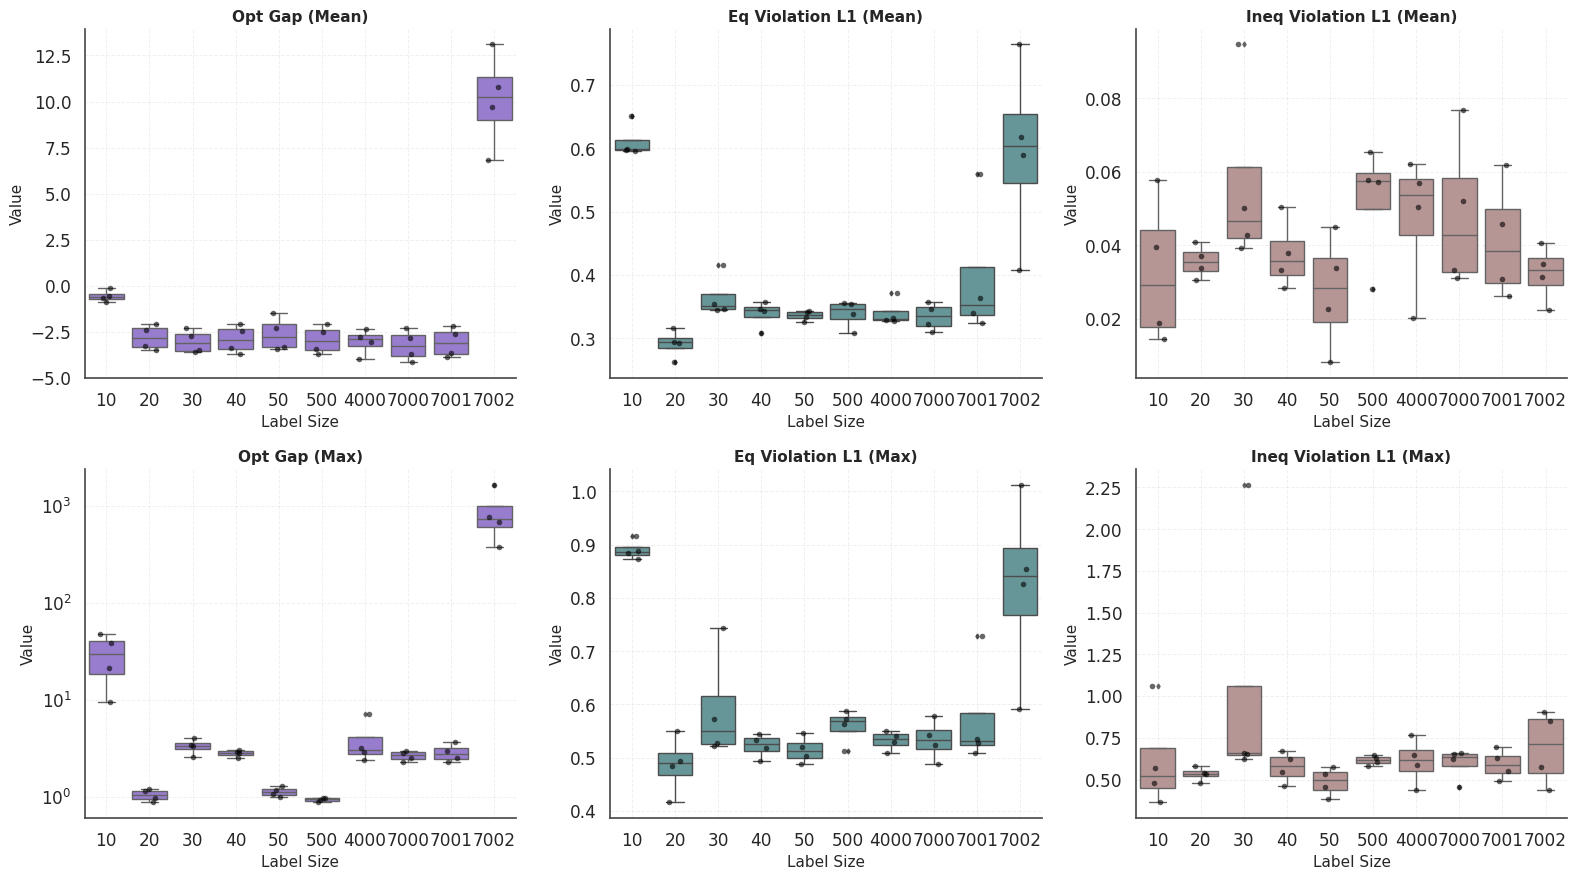

In [ ]:
# PLOTS FOR DIFFERENT TRAINING DATASET SIZES
train_sizes = np.array([10, 20, 30, 40, 50, 200, 500, 1000, 4000, 7000, 7001, 7002])
select = [0,1,2,3,4,6,8,9,10,11]
# select = [0, 1, 2, 3, 4, -2, -3, -1]

# plot_box_with_points(
#     [opt_gap_mean],
#     ["Opt Gap (Mean)"],
#     train_sizes,
#     x_label="Training Dataset Sizes",
#     title="",
#     log_scale_y=False,
#     figsize=(5, 4),
# )

metrics = [ 
    (opt_gap_mean[select], "Opt Gap (Mean)", False, colors[-1]),
    (eq_violation_l1_mean[select], "Eq Violation L1 (Mean)", False, colors[1]),
    (ineq_violation_l1_mean[select], "Ineq Violation L1 (Mean)", False, colors[2]),
    (opt_gap_max[select], "Opt Gap (Max)", True, colors[-1]),
    (eq_violation_l1_max[select], "Eq Violation L1 (Max)", False, colors[1]),
    (ineq_violation_l1_max[select], "Ineq Violation L1 (Max)", False, colors[2]),
]

plot_metrics_grid(
    metrics,
    train_sizes[select],
    nrows=2, ncols=3,
    figsize=(16, 9),
    x_label="Label Size",
    y_label="Value",
)

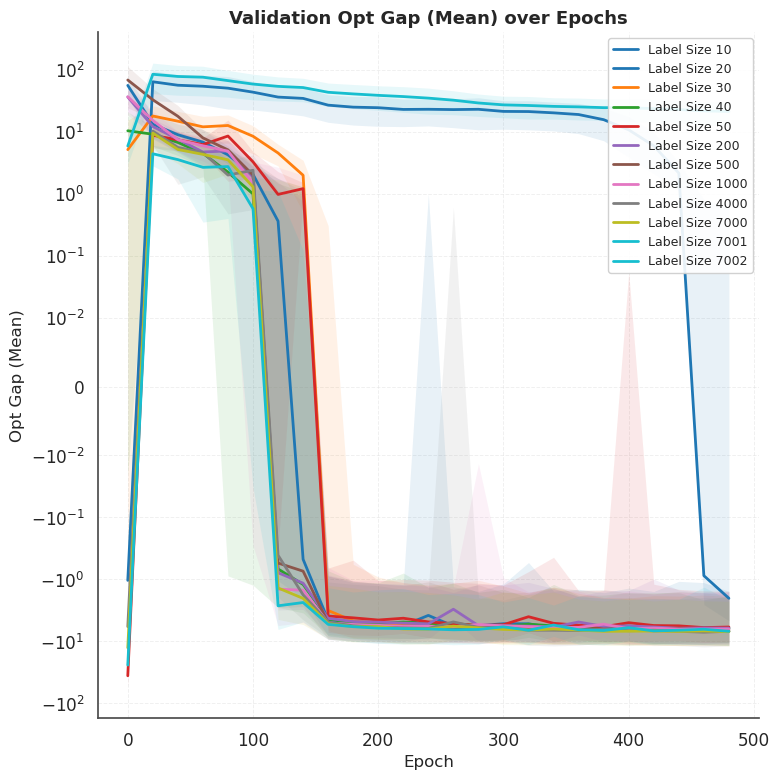

In [ ]:
# select = [0,1,2,3,4,5,6,7]
select = [0,1,2,3,4,5,6,7,8,9,10,11]
plot_metric_over_epochs(
    metric_array=opt_gap_mean_epochs[select],   # shape [num_ckpts, num_seeds, num_epochs]
    baselines=train_sizes[select],
    metric_name="Opt Gap (Mean)",
    label="Label Size",
    # title="Validation Opt Gap Mean per Checkpoint",
    log_scale_y=True,        # set False if values are small
    epochs_per_val=20,
    colors="tab10",
    figsize=(8, 8),
)